In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd


In [2]:
df = pd.read_excel(r'C:\Programming\ETH\SS26\ISQT26\market_autoencoder\data.xlsx',
                   sheet_name='Raw Data', engine='openpyxl', header=3)
df = df.rename(columns={df.columns[0]: 'Date'})
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date']).set_index('Date')
df = df.loc[:, ~df.columns.astype(str).str.startswith('Unnamed')]   # drop blank spacer column

C:\Users\trist\AppData\Local\Temp\ipykernel_37536\4135330000.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 627 entries, 1973-01-31 to 2025-03-31
Data columns (total 8 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   US-DS Market - PER                        627 non-null    object 
 1   US GVT EVAL BMK BID YLD 10Y - RED. YIELD  627 non-null    object 
 2   US CPI - ALL URBAN: ALL ITEMS SADJ        627 non-null    object 
 3   TOTMKUS(PI)/TOTMKUS(PE)                   627 non-null    object 
 4   US GVT EVAL BMK BID YLD 3M - RED. YIELD   627 non-null    object 
 5   12M FWD E                                 495 non-null    float64
 6   Real Yield                                507 non-null    float64
 7   Steepness                                 507 non-null    float64
dtypes: float64(3), object(5)
memory usage: 44.1+ KB


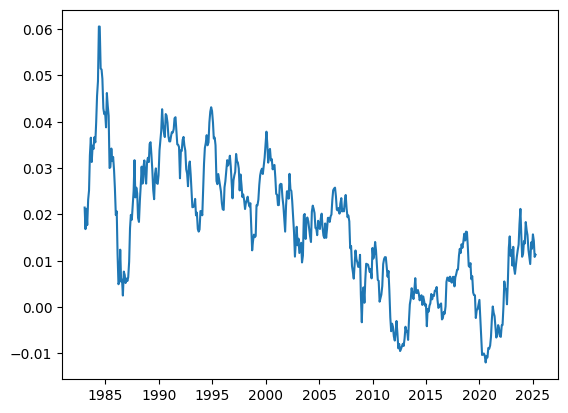

In [4]:
plt.plot(df["Real Yield"])
plt.show()

In [5]:
from sklearn.preprocessing import MinMaxScaler
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# ----------------------------
# 1. Clean numeric dataframe
# ----------------------------
df_num = df.copy()

for c in df_num.columns:
    df_num[c] = pd.to_numeric(df_num[c], errors="coerce")

df_num = df_num.dropna().sort_index()

target_col = "Real Yield"

# Use all 8 columns as lagged inputs, including lagged Real Yield.
# This is okay because the model only sees past windows, not y_t itself.
feature_cols = list(df_num.columns)

X_raw = df_num[feature_cols].values.astype(float)
y_raw = df_num[[target_col]].values.astype(float)

print(df_num.shape)
print(feature_cols)

(495, 8)
['US-DS Market - PER', 'US GVT EVAL BMK BID YLD 10Y - RED. YIELD', 'US CPI - ALL URBAN: ALL ITEMS SADJ', 'TOTMKUS(PI)/TOTMKUS(PE)', 'US GVT EVAL BMK BID YLD 3M - RED. YIELD', '12M FWD E', 'Real Yield', 'Steepness']


In [6]:
# ----------------------------
# 2. Chronological split + train-only scaling
# ----------------------------
TEST_N = 30

X_train_raw, X_test_raw = X_raw[:-TEST_N], X_raw[-TEST_N:]
y_train_raw, y_test_raw = y_raw[:-TEST_N], y_raw[-TEST_N:]

x_scaler = MinMaxScaler(feature_range=(-1, 1)).fit(X_train_raw)
y_scaler = MinMaxScaler(feature_range=(-1, 1)).fit(y_train_raw)

Xtr = torch.tensor(x_scaler.transform(X_train_raw), dtype=torch.float32)
Xte = torch.tensor(x_scaler.transform(X_test_raw), dtype=torch.float32)

Ytr = torch.tensor(y_scaler.transform(y_train_raw), dtype=torch.float32)
Yte = torch.tensor(y_scaler.transform(y_test_raw), dtype=torch.float32)

print(Xtr.shape, Xte.shape)
print(Ytr.shape, Yte.shape)

torch.Size([465, 8]) torch.Size([30, 8])
torch.Size([465, 1]) torch.Size([30, 1])


In [7]:
# ----------------------------
# 3. Build lookback data
# ----------------------------
def make_seq_data(L=20):
    X_all = torch.cat([Xtr, Xte], dim=0)
    Y_all = torch.cat([Ytr, Yte], dim=0)

    Xs, Ys = [], []
    for i in range(len(X_all) - L):
        Xs.append(X_all[i:i+L])   # [X_{t-L}, ..., X_{t-1}]
        Ys.append(Y_all[i+L])     # y_t

    Xs = torch.stack(Xs)          # [samples, L, n_features]
    Ys = torch.stack(Ys)          # [samples, 1]

    split = len(Xtr) - L
    return Xs[:split], Xs[split:], Ys[:split], Ys[split:]


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true.ravel() - y_pred.ravel()) ** 2))


def hit_ratio_np(y_true, y_pred):
    y_true = y_true.ravel()
    y_pred = y_pred.ravel()

    if len(y_true) < 2:
        return np.nan

    actual_dir = np.sign(np.diff(y_true))
    pred_dir = np.sign(np.diff(y_pred))

    return np.mean(actual_dir == pred_dir)


def hit_ratio_torch(y_true, y_pred):
    if len(y_true) < 2:
        return np.nan

    actual_dir = torch.sign(y_true[1:] - y_true[:-1])
    pred_dir = torch.sign(y_pred[1:] - y_pred[:-1])

    return float((actual_dir == pred_dir).float().mean())

In [8]:
# ----------------------------
# 4. Run one seed: RNN or MLP
# ----------------------------
def run_seed(seed, arch="rnn", L=20, hidden_size=8, epochs=1000, lr=0.01, weight_decay=1e-4):
    torch.manual_seed(int(seed))
    np.random.seed(int(seed))

    Xtr_seq, Xte_seq, Ytr_seq, Yte_seq = make_seq_data(L=L)

    n_features = Xtr_seq.shape[-1]

    if arch == "rnn":
        rnn = torch.nn.RNN(
            input_size=n_features,
            hidden_size=hidden_size,
            batch_first=True
        )
        out = torch.nn.Linear(hidden_size, 1)
        params = list(rnn.parameters()) + list(out.parameters())

    elif arch == "mlp":
        mlp = torch.nn.Sequential(
            torch.nn.Linear(L * n_features, hidden_size),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_size, 1)
        )
        params = mlp.parameters()

    else:
        raise ValueError("arch must be 'rnn' or 'mlp'")

    opt = torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    loss_fn = torch.nn.MSELoss()

    train_losses, test_losses = [], []
    train_hits, test_hits = [], []

    for epoch in range(epochs):
        opt.zero_grad()

        if arch == "rnn":
            htr, _ = rnn(Xtr_seq)
            train_pred_scaled = out(htr[:, -1, :])
        else:
            train_pred_scaled = mlp(Xtr_seq.reshape(Xtr_seq.shape[0], -1))

        train_loss = loss_fn(train_pred_scaled, Ytr_seq)
        train_loss.backward()
        opt.step()

        with torch.no_grad():
            if arch == "rnn":
                hte, _ = rnn(Xte_seq)
                test_pred_scaled = out(hte[:, -1, :])
            else:
                test_pred_scaled = mlp(Xte_seq.reshape(Xte_seq.shape[0], -1))

            test_loss = loss_fn(test_pred_scaled, Yte_seq)

            train_hits.append(hit_ratio_torch(Ytr_seq, train_pred_scaled))
            test_hits.append(hit_ratio_torch(Yte_seq, test_pred_scaled))

        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())

    with torch.no_grad():
        if arch == "rnn":
            htr, _ = rnn(Xtr_seq)
            train_pred = out(htr[:, -1, :])

            hte, _ = rnn(Xte_seq)
            test_pred = out(hte[:, -1, :])
        else:
            train_pred = mlp(Xtr_seq.reshape(Xtr_seq.shape[0], -1))
            test_pred = mlp(Xte_seq.reshape(Xte_seq.shape[0], -1))

    train_pred_np = y_scaler.inverse_transform(train_pred.numpy())
    test_pred_np = y_scaler.inverse_transform(test_pred.numpy())

    Ytr_seq_np = y_scaler.inverse_transform(Ytr_seq.numpy())
    Yte_seq_np = y_scaler.inverse_transform(Yte_seq.numpy())

    return {
        "arch": arch,
        "seed": seed,
        "train_losses": train_losses,
        "test_losses": test_losses,
        "train_hits": train_hits,
        "test_hits": test_hits,
        "train_pred_np": train_pred_np,
        "test_pred_np": test_pred_np,
        "Ytr_seq_np": Ytr_seq_np,
        "Yte_seq_np": Yte_seq_np,
        "train_rmse": rmse(Ytr_seq_np, train_pred_np),
        "test_rmse": rmse(Yte_seq_np, test_pred_np),
        "train_hit": hit_ratio_np(Ytr_seq_np, train_pred_np),
        "test_hit": hit_ratio_np(Yte_seq_np, test_pred_np),
    }

In [9]:
# ----------------------------
# 5. Seed grid
# ----------------------------
L = 5
seeds = np.random.randint(0, 100, 10)

jobs = [(arch, s) for arch in ["rnn", "mlp"] for s in seeds]

results = []

for arch, s in tqdm(jobs, desc="Running RNN/MLP seed grid"):
    results.append(
        run_seed(
            seed=s,
            arch=arch,
            L=L,
            hidden_size=8,
            epochs=1000,
            lr=0.01,
            weight_decay=1e-4
        )
    )

summary = pd.DataFrame([
    {
        "arch": r["arch"],
        "seed": r["seed"],
        "train_rmse": r["train_rmse"],
        "test_rmse": r["test_rmse"],
        "train_hit": r["train_hit"],
        "test_hit": r["test_hit"],
        "final_train_loss": r["train_losses"][-1],
        "final_test_loss": r["test_losses"][-1],
    }
    for r in results
])

display(summary.sort_values(["arch", "test_rmse"]))

Running RNN/MLP seed grid:   0%|          | 0/20 [00:00<?, ?it/s]

,arch,seed,train_rmse,test_rmse,train_hit,test_hit,final_train_loss,final_test_loss
14,mlp,27,0.002484,0.004190,0.557734,0.551724,0.004694,0.013348
13,mlp,78,0.002569,0.004596,0.562092,0.448276,0.005020,0.016063
11,mlp,99,0.002522,0.004715,0.557734,0.517241,0.004839,0.016904
17,mlp,70,0.002473,0.005694,0.562092,0.517241,0.004652,0.024658
10,mlp,95,0.002443,0.005720,0.566449,0.517241,0.004541,0.024883
16,mlp,75,0.002370,0.005745,0.566449,0.517241,0.004271,0.025097
12,mlp,52,0.002432,0.006293,0.553377,0.586207,0.004497,0.030117
15,mlp,67,0.002400,0.006560,0.562092,0.482759,0.004382,0.032727
18,mlp,57,0.002469,0.008058,0.564270,0.517241,0.004637,0.049376
19,mlp,81,0.002334,0.008977,0.575163,0.551724,0.004142,0.061283


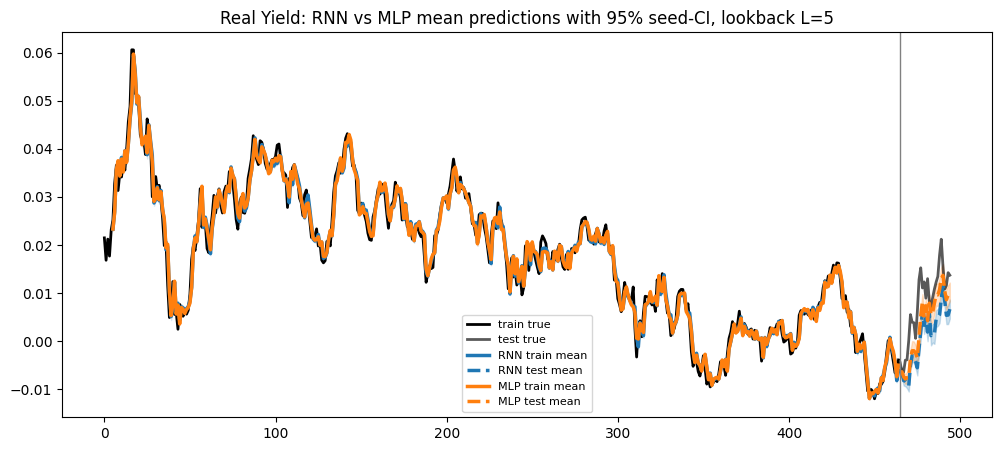

In [10]:
# ----------------------------
# 6. Mean + 95% seed-CI prediction plot
# ----------------------------
def mean_ci(arrs):
    A = np.stack([a.ravel() for a in arrs], axis=0)
    mean = A.mean(axis=0)
    se = A.std(axis=0, ddof=1) / np.sqrt(A.shape[0])
    lo = mean - 1.96 * se
    hi = mean + 1.96 * se
    return mean, lo, hi


Ytr_np = y_scaler.inverse_transform(Ytr.numpy()).ravel()
Yte_np = y_scaler.inverse_transform(Yte.numpy()).ravel()

train_idx_old = np.arange(len(Ytr_np))
test_idx_old = np.arange(len(Ytr_np), len(Ytr_np) + len(Yte_np))

train_idx_seq = np.arange(L, len(Ytr_np))
test_idx_seq = np.arange(len(Ytr_np), len(Ytr_np) + len(Yte_np))

plt.figure(figsize=(12, 5))

plt.plot(train_idx_old, Ytr_np, color="black", linewidth=2, label="train true")
plt.plot(test_idx_old, Yte_np, color="black", linewidth=2, alpha=0.65, label="test true")

for arch, color in [("rnn", "C0"), ("mlp", "C1")]:
    sub = [r for r in results if r["arch"] == arch]

    train_mean, train_lo, train_hi = mean_ci([r["train_pred_np"] for r in sub])
    test_mean, test_lo, test_hi = mean_ci([r["test_pred_np"] for r in sub])

    plt.plot(train_idx_seq, train_mean, color=color, linewidth=2.5, label=f"{arch.upper()} train mean")
    plt.fill_between(train_idx_seq, train_lo, train_hi, color=color, alpha=0.15)

    plt.plot(test_idx_seq, test_mean, color=color, linestyle="--", linewidth=2.5, label=f"{arch.upper()} test mean")
    plt.fill_between(test_idx_seq, test_lo, test_hi, color=color, alpha=0.22)

plt.axvline(len(Ytr_np), color="grey", linewidth=1)
plt.title(f"{target_col}: RNN vs MLP mean predictions with 95% seed-CI, lookback L={L}")
plt.legend(fontsize=8)
plt.show()

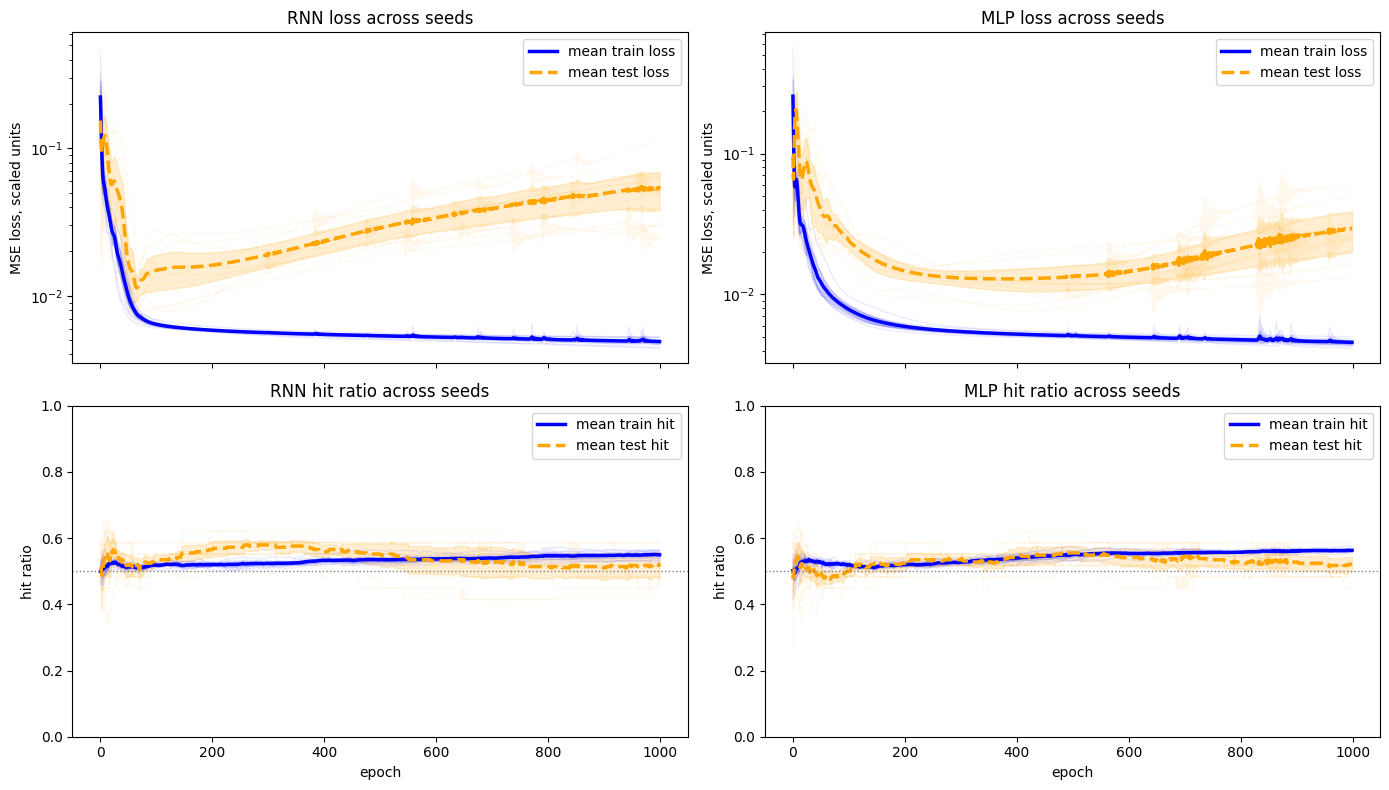

In [11]:
# ----------------------------
# 7. Loss + hit ratio over epochs
# ----------------------------
def mean_ci_series(series_list):
    A = np.array(series_list, dtype=float)
    mean = np.nanmean(A, axis=0)
    se = np.nanstd(A, axis=0, ddof=1) / np.sqrt(A.shape[0])
    lo = mean - 1.96 * se
    hi = mean + 1.96 * se
    return mean, lo, hi


fig, ax = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for j, arch in enumerate(["rnn", "mlp"]):
    sub = [r for r in results if r["arch"] == arch]
    epochs_idx = np.arange(len(sub[0]["train_losses"]))

    train_mean, train_lo, train_hi = mean_ci_series([r["train_losses"] for r in sub])
    test_mean, test_lo, test_hi = mean_ci_series([r["test_losses"] for r in sub])

    for r in sub:
        ax[0, j].plot(r["train_losses"], alpha=0.08, linewidth=1.0, color="blue")
        ax[0, j].plot(r["test_losses"], "--", alpha=0.08, linewidth=1.0, color="orange")

    ax[0, j].plot(epochs_idx, train_mean, color="blue", linewidth=2.5, label="mean train loss")
    ax[0, j].fill_between(epochs_idx, train_lo, train_hi, color="blue", alpha=0.15)

    ax[0, j].plot(epochs_idx, test_mean, "--", color="orange", linewidth=2.5, label="mean test loss")
    ax[0, j].fill_between(epochs_idx, test_lo, test_hi, color="orange", alpha=0.18)

    ax[0, j].set_yscale("log")
    ax[0, j].set_title(f"{arch.upper()} loss across seeds")
    ax[0, j].set_ylabel("MSE loss, scaled units")
    ax[0, j].legend()

    train_hit_mean, train_hit_lo, train_hit_hi = mean_ci_series([r["train_hits"] for r in sub])
    test_hit_mean, test_hit_lo, test_hit_hi = mean_ci_series([r["test_hits"] for r in sub])

    for r in sub:
        ax[1, j].plot(r["train_hits"], alpha=0.08, linewidth=1.0, color="blue")
        ax[1, j].plot(r["test_hits"], "--", alpha=0.08, linewidth=1.0, color="orange")

    ax[1, j].plot(epochs_idx, train_hit_mean, color="blue", linewidth=2.5, label="mean train hit")
    ax[1, j].fill_between(epochs_idx, train_hit_lo, train_hit_hi, color="blue", alpha=0.15)

    ax[1, j].plot(epochs_idx, test_hit_mean, "--", color="orange", linewidth=2.5, label="mean test hit")
    ax[1, j].fill_between(epochs_idx, test_hit_lo, test_hit_hi, color="orange", alpha=0.18)

    ax[1, j].axhline(0.5, color="grey", linewidth=1, linestyle=":")
    ax[1, j].set_title(f"{arch.upper()} hit ratio across seeds")
    ax[1, j].set_xlabel("epoch")
    ax[1, j].set_ylabel("hit ratio")
    ax[1, j].set_ylim(0, 1)
    ax[1, j].legend()

plt.tight_layout()
plt.show()

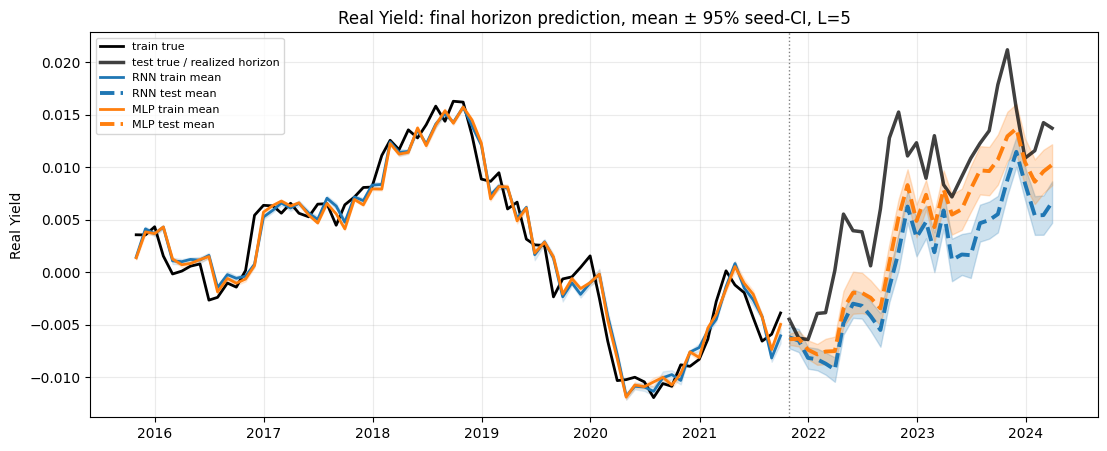

In [12]:
# ----------------------------
# Final horizon prediction plot: actual dates + back-transformed data
# ----------------------------

def mean_ci(arrs):
    A = np.stack([a.ravel() for a in arrs], axis=0)
    mean = A.mean(axis=0)
    se = A.std(axis=0, ddof=1) / np.sqrt(A.shape[0])
    lo = mean - 1.96 * se
    hi = mean + 1.96 * se
    return mean, lo, hi

# dates aligned with current train/test split
dates_all = df_num.index
train_dates = dates_all[:len(Ytr)]
test_dates  = dates_all[len(Ytr):len(Ytr) + len(Yte)]

# back-transformed true yields
Ytr_np = y_scaler.inverse_transform(Ytr.numpy()).ravel()
Yte_np = y_scaler.inverse_transform(Yte.numpy()).ravel()

# sequence predictions start after lookback L in train, but test starts exactly at test_dates
train_seq_dates = train_dates[L:]
test_seq_dates  = test_dates

plt.figure(figsize=(13, 5))

# show a bit of history before the final 12m horizon
history_months = 72
hist_start = max(0, len(train_dates) - history_months)

plt.plot(train_dates[hist_start:], Ytr_np[hist_start:], color="black", linewidth=2, label="train true")
plt.plot(test_dates, Yte_np, color="black", linewidth=2.5, alpha=0.75, label="test true / realized horizon")

for arch, color in [("rnn", "C0"), ("mlp", "C1")]:
    sub = [r for r in results if r["arch"] == arch]

    train_mean, train_lo, train_hi = mean_ci([r["train_pred_np"] for r in sub])
    test_mean, test_lo, test_hi = mean_ci([r["test_pred_np"] for r in sub])

    # train prediction only over the visible history
    visible = train_seq_dates >= train_dates[hist_start]

    plt.plot(train_seq_dates[visible], train_mean[visible], color=color, linewidth=2.0,
             label=f"{arch.upper()} train mean")
    plt.fill_between(train_seq_dates[visible], train_lo[visible], train_hi[visible],
                     color=color, alpha=0.12)

    # final 12m test horizon
    plt.plot(test_seq_dates, test_mean, color=color, linestyle="--", linewidth=2.8,
             label=f"{arch.upper()} test mean")
    plt.fill_between(test_seq_dates, test_lo, test_hi, color=color, alpha=0.22)

plt.axvline(test_dates[0], color="grey", linewidth=1, linestyle=":")
plt.title(f"{target_col}: final horizon prediction, mean ± 95% seed-CI, L={L}")
plt.ylabel(target_col)
plt.legend(fontsize=8)
plt.grid(alpha=0.25)
plt.show()

In [13]:
# ----------------------------
# Fast monthly test-only strategy, acting ONLY on mean prediction across seeds
#
# At each test month m:
# - compute mean predicted next-month yield change across seeds
# - buy bond if predicted yield falls by more than threshold
# - short bond if predicted yield rises by more than threshold
# - P&L uses actual next-month bond price change
#
# Assumes yields are decimal units:
# 50bp = 0.005
# 5bp  = 0.0005
# ----------------------------

threshold_bp = 30
threshold = threshold_bp / 10_000

cost_bp = 1
notional = 100
cost_per_trade = notional * cost_bp / 10_000
maturity = 10

def naive_bond_price(y_decimal, maturity=10, notional=100):
    return notional / (1 + np.asarray(y_decimal)) ** maturity

# test-only realized path
y_realized_path = np.r_[Ytr_np[-1], Yte_np]
price_realized_path = naive_bond_price(y_realized_path, maturity=maturity, notional=notional)

actual_price_change = np.diff(price_realized_path)
actual_yield_change = np.diff(y_realized_path)

trade_dates = test_dates

strategy_rows = []
monthly_pnl_store = {}
position_store = {}
mean_pred_store = {}

for arch in ["rnn", "mlp"]:
    sub = [r for r in results if r["arch"] == arch]

    # mean predicted yield path across seeds, test horizon only
    pred_y_stack = np.stack([r["test_pred_np"].ravel() for r in sub], axis=0)
    pred_y_mean = pred_y_stack.mean(axis=0)

    # path starts from final train observation
    pred_path = np.r_[Ytr_np[-1], pred_y_mean]

    # predicted next-month yield changes
    pred_next_yield_change = np.diff(pred_path)

    # act only on mean predicted change
    positions = np.where(
        pred_next_yield_change <= -threshold, 1,
        np.where(pred_next_yield_change >= threshold, -1, 0)
    )

    # actual monthly P&L from realized bond-price changes
    monthly_pnl = positions * actual_price_change

    # transaction cost when position changes from previous month
    prev_positions = np.r_[0, positions[:-1]]
    turnover_entry_rebalance = np.abs(positions - prev_positions)

    # close remaining position at end of horizon
    turnover_exit = abs(positions[-1])

    monthly_pnl = monthly_pnl - turnover_entry_rebalance * cost_per_trade
    monthly_pnl[-1] -= turnover_exit * cost_per_trade

    total_turnover = turnover_entry_rebalance.sum() + turnover_exit
    total_cost_paid = total_turnover * cost_per_trade

    total_pnl = monthly_pnl.sum()
    sd = monthly_pnl.std(ddof=1)
    sharpe = monthly_pnl.mean() / sd * np.sqrt(12) if sd > 0 else np.nan

    active = positions != 0
    active_win_rate = np.mean(monthly_pnl[active] > 0) if active.sum() > 0 else np.nan

    strategy_rows.append({
        "arch": arch,
        "threshold_bp": threshold_bp,
        "n_seed_models": len(sub),
        "origin_date": train_dates[-1],
        "end_date": test_dates[-1],
        "y0": Ytr_np[-1],
        "realized_y_end": Yte_np[-1],
        "mean_pred_y_end": pred_y_mean[-1],
        "mean_pred_12m_yield_change": pred_y_mean[-1] - Ytr_np[-1],
        "actual_12m_yield_change": Yte_np[-1] - Ytr_np[-1],
        "total_pnl": total_pnl,
        "mean_monthly_pnl": monthly_pnl.mean(),
        "vol_monthly_pnl": sd,
        "sharpe_ann": sharpe,
        "active_win_rate": active_win_rate,
        "n_long_months": np.sum(positions == 1),
        "n_short_months": np.sum(positions == -1),
        "n_flat_months": np.sum(positions == 0),
        "turnover": total_turnover,
        "cost_paid": total_cost_paid,
    })

    monthly_pnl_store[arch] = monthly_pnl
    position_store[arch] = positions
    mean_pred_store[arch] = pred_y_mean

strategy_tbl = pd.DataFrame(strategy_rows)
display(strategy_tbl)

,arch,threshold_bp,n_seed_models,origin_date,end_date,y0,realized_y_end,mean_pred_y_end,mean_pred_12m_yield_change,actual_12m_yield_change,total_pnl,mean_monthly_pnl,vol_monthly_pnl,sharpe_ann,active_win_rate,n_long_months,n_short_months,n_flat_months,turnover,cost_paid
0,rnn,30,10,2021-09-30,2024-03-29,-0.003885,0.013726,0.006679,0.010565,0.017612,13.939819,0.464661,2.028517,0.793502,0.7,3,7,20,14,0.14
1,mlp,30,10,2021-09-30,2024-03-29,-0.003885,0.013726,0.010243,0.014129,0.017612,4.887019,0.162901,2.110560,0.267372,0.5,3,5,22,12,0.12


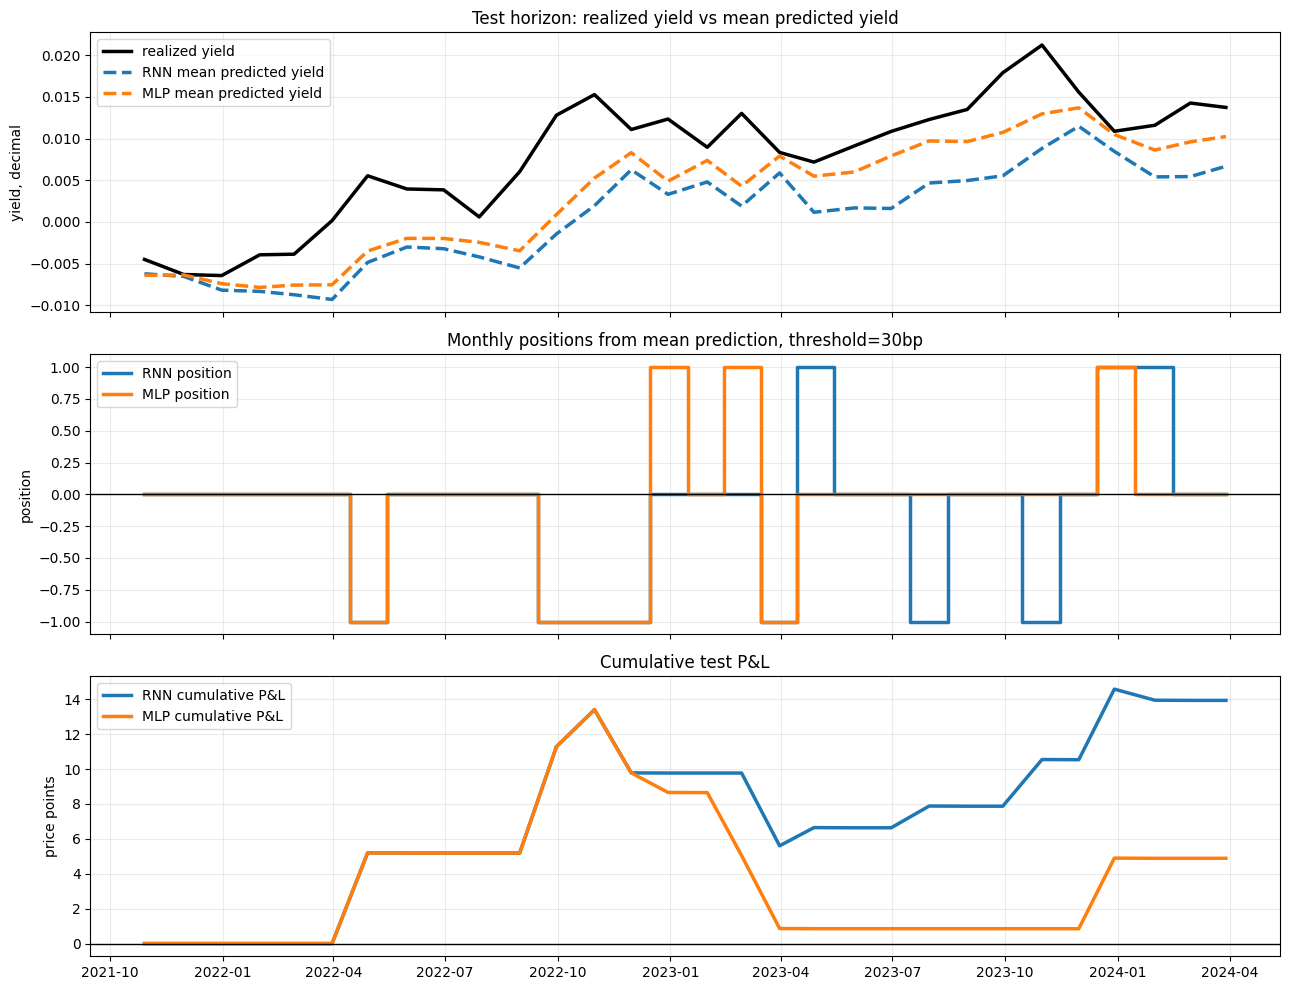

In [14]:
# ----------------------------
# Plots: mean prediction, positions, cumulative P&L
# ----------------------------

fig, ax = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# 1. Realized vs mean predicted yield path
ax[0].plot(test_dates, Yte_np, color="black", linewidth=2.5, label="realized yield")

for arch, color in [("rnn", "C0"), ("mlp", "C1")]:
    ax[0].plot(test_dates, mean_pred_store[arch], "--", color=color, linewidth=2.5,
               label=f"{arch.upper()} mean predicted yield")

ax[0].set_title("Test horizon: realized yield vs mean predicted yield")
ax[0].set_ylabel("yield, decimal")
ax[0].legend()
ax[0].grid(alpha=0.25)

# 2. Positions
for arch, color in [("rnn", "C0"), ("mlp", "C1")]:
    ax[1].step(test_dates, position_store[arch], where="mid", color=color, linewidth=2.5,
               label=f"{arch.upper()} position")

ax[1].axhline(0, color="black", linewidth=1)
ax[1].set_title(f"Monthly positions from mean prediction, threshold={threshold_bp}bp")
ax[1].set_ylabel("position")
ax[1].legend()
ax[1].grid(alpha=0.25)

# 3. Cumulative P&L
for arch, color in [("rnn", "C0"), ("mlp", "C1")]:
    ax[2].plot(test_dates, np.cumsum(monthly_pnl_store[arch]), color=color, linewidth=2.5,
               label=f"{arch.upper()} cumulative P&L")

ax[2].axhline(0, color="black", linewidth=1)
ax[2].set_title("Cumulative test P&L")
ax[2].set_ylabel("price points")
ax[2].legend()
ax[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [15]:
# ----------------------------
# Walk-forward RNN/MLP strategy validation
# Train on past only -> predict next H months -> trade mean prediction only
# ----------------------------

from sklearn.preprocessing import MinMaxScaler
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# ----------------------------
# Config
# ----------------------------
target_col = "Real Yield"
feature_cols = list(df_num.columns)

L = 5
H = 12                  # test block length in months
STEP = 12               # non-overlapping test blocks
TRAIN_MIN = 240         # minimum initial training sample
hidden_size = 8
epochs = 500
lr = 0.01
weight_decay = 1e-4
seeds = np.random.randint(0, 100, 10)

threshold_bp = 30
threshold = threshold_bp / 10_000

spread_256ths = 4.5
notional = 100
maturity = 10

cost_per_trade = (spread_256ths / 256) / 2
cost_bp = cost_per_trade / notional * 10_000

print(f"One-way cost: {cost_bp:.2f} bp of notional")
print(f"Threshold: {threshold_bp} bp")


# ----------------------------
# Helpers
# ----------------------------
def naive_bond_price(y_decimal, maturity=10, notional=100):
    return notional / (1 + np.asarray(y_decimal)) ** maturity


def make_seq_data_fold(X_train, X_test, Y_train, Y_test, L):
    X_all = torch.cat([X_train, X_test], dim=0)
    Y_all = torch.cat([Y_train, Y_test], dim=0)

    Xs, Ys = [], []
    for i in range(len(X_all) - L):
        Xs.append(X_all[i:i+L])
        Ys.append(Y_all[i+L])

    Xs = torch.stack(Xs)
    Ys = torch.stack(Ys)

    split = len(X_train) - L
    return Xs[:split], Xs[split:], Ys[:split], Ys[split:]


def train_predict_one_seed(
    X_train, X_test, Y_train, Y_test,
    y_scaler,
    seed,
    arch="rnn",
    L=20,
    hidden_size=8,
    epochs=500,
    lr=0.01,
    weight_decay=1e-4
):
    torch.manual_seed(int(seed))
    np.random.seed(int(seed))

    Xtr_seq, Xte_seq, Ytr_seq, Yte_seq = make_seq_data_fold(X_train, X_test, Y_train, Y_test, L)
    n_features = Xtr_seq.shape[-1]

    if arch == "rnn":
        rnn = torch.nn.RNN(
            input_size=n_features,
            hidden_size=hidden_size,
            batch_first=True
        )
        out = torch.nn.Linear(hidden_size, 1)
        params = list(rnn.parameters()) + list(out.parameters())

    elif arch == "mlp":
        mlp = torch.nn.Sequential(
            torch.nn.Linear(L * n_features, hidden_size),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_size, 1)
        )
        params = mlp.parameters()

    else:
        raise ValueError("arch must be 'rnn' or 'mlp'")

    opt = torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    loss_fn = torch.nn.MSELoss()

    for epoch in range(epochs):
        opt.zero_grad()

        if arch == "rnn":
            htr, _ = rnn(Xtr_seq)
            pred = out(htr[:, -1, :])
        else:
            pred = mlp(Xtr_seq.reshape(Xtr_seq.shape[0], -1))

        loss = loss_fn(pred, Ytr_seq)
        loss.backward()
        opt.step()

    with torch.no_grad():
        if arch == "rnn":
            hte, _ = rnn(Xte_seq)
            pred_test = out(hte[:, -1, :])
        else:
            pred_test = mlp(Xte_seq.reshape(Xte_seq.shape[0], -1))

    pred_test_np = y_scaler.inverse_transform(pred_test.numpy()).ravel()
    return pred_test_np


def sharpe_ann(x):
    x = np.asarray(x, dtype=float)
    sd = x.std(ddof=1)
    return x.mean() / sd * np.sqrt(12) if sd > 0 else np.nan


# ----------------------------
# Data arrays
# ----------------------------
df_bt = df_num[feature_cols].copy().dropna().sort_index()
dates = df_bt.index

X_all_raw = df_bt[feature_cols].values.astype(float)
y_all_raw = df_bt[[target_col]].values.astype(float).ravel()

fold_rows = []
monthly_rows = []

fold_starts = range(TRAIN_MIN, len(df_bt) - H + 1, STEP)

for fold_id, train_end in enumerate(tqdm(fold_starts, desc="Walk-forward folds")):
    test_start = train_end
    test_end = train_end + H

    X_train_raw = X_all_raw[:train_end]
    X_test_raw  = X_all_raw[test_start:test_end]

    y_train_raw = y_all_raw[:train_end].reshape(-1, 1)
    y_test_raw  = y_all_raw[test_start:test_end].reshape(-1, 1)

    x_scaler = MinMaxScaler(feature_range=(-1, 1)).fit(X_train_raw)
    y_scaler = MinMaxScaler(feature_range=(-1, 1)).fit(y_train_raw)

    X_train = torch.tensor(x_scaler.transform(X_train_raw), dtype=torch.float32)
    X_test  = torch.tensor(x_scaler.transform(X_test_raw), dtype=torch.float32)

    Y_train = torch.tensor(y_scaler.transform(y_train_raw), dtype=torch.float32)
    Y_test  = torch.tensor(y_scaler.transform(y_test_raw), dtype=torch.float32)

    y0 = y_all_raw[train_end - 1]
    y_realized_path = np.r_[y0, y_all_raw[test_start:test_end]]

    price_realized_path = naive_bond_price(y_realized_path, maturity=maturity, notional=notional)
    actual_price_change = np.diff(price_realized_path)
    actual_yield_change = np.diff(y_realized_path)

    test_dates_fold = dates[test_start:test_end]

    for arch in ["rnn", "mlp"]:
        seed_preds = []

        for s in seeds:
            pred_test_np = train_predict_one_seed(
                X_train, X_test, Y_train, Y_test,
                y_scaler=y_scaler,
                seed=s,
                arch=arch,
                L=L,
                hidden_size=hidden_size,
                epochs=epochs,
                lr=lr,
                weight_decay=weight_decay
            )
            seed_preds.append(pred_test_np)

        pred_mean = np.stack(seed_preds, axis=0).mean(axis=0)

        pred_path = np.r_[y0, pred_mean]
        pred_next_yield_change = np.diff(pred_path)

        positions = np.where(
            pred_next_yield_change <= -threshold, 1,
            np.where(pred_next_yield_change >= threshold, -1, 0)
        )

        monthly_pnl = positions * actual_price_change

        prev_positions = np.r_[0, positions[:-1]]
        turnover_entry_rebalance = np.abs(positions - prev_positions)
        turnover_exit = abs(positions[-1])

        monthly_pnl = monthly_pnl - turnover_entry_rebalance * cost_per_trade
        monthly_pnl[-1] -= turnover_exit * cost_per_trade

        total_turnover = turnover_entry_rebalance.sum() + turnover_exit
        total_cost = total_turnover * cost_per_trade

        fold_rows.append({
            "fold_id": fold_id,
            "arch": arch,
            "train_end": dates[train_end - 1],
            "test_start": dates[test_start],
            "test_end": dates[test_end - 1],
            "threshold_bp": threshold_bp,
            "total_pnl": monthly_pnl.sum(),
            "total_pnl_bp": monthly_pnl.sum() / notional * 10_000,
            "sharpe_ann": sharpe_ann(monthly_pnl),
            "mean_monthly_pnl": monthly_pnl.mean(),
            "vol_monthly_pnl": monthly_pnl.std(ddof=1),
            "n_long": np.sum(positions == 1),
            "n_short": np.sum(positions == -1),
            "n_flat": np.sum(positions == 0),
            "turnover": total_turnover,
            "cost_paid": total_cost,
            "hit_rate_active": np.mean(monthly_pnl[positions != 0] > 0) if np.any(positions != 0) else np.nan,
            "actual_yield_change": y_realized_path[-1] - y_realized_path[0],
            "pred_yield_change": pred_mean[-1] - y0,
        })

        for i in range(H):
            monthly_rows.append({
                "date": test_dates_fold[i],
                "fold_id": fold_id,
                "arch": arch,
                "actual_yield": y_all_raw[test_start + i],
                "pred_yield": pred_mean[i],
                "pred_next_yield_change": pred_next_yield_change[i],
                "actual_next_yield_change": actual_yield_change[i],
                "position": positions[i],
                "monthly_pnl": monthly_pnl[i],
                "monthly_pnl_bp": monthly_pnl[i] / notional * 10_000,
                "actual_price_change": actual_price_change[i],
            })

fold_tbl = pd.DataFrame(fold_rows)
monthly_tbl = pd.DataFrame(monthly_rows)

display(fold_tbl)

One-way cost: 0.88 bp of notional
Threshold: 30 bp


Walk-forward folds:   0%|          | 0/21 [00:00<?, ?it/s]

,fold_id,arch,train_end,test_start,test_end,threshold_bp,total_pnl,total_pnl_bp,sharpe_ann,mean_monthly_pnl,vol_monthly_pnl,n_long,n_short,n_flat,turnover,cost_paid,hit_rate_active,actual_yield_change,pred_yield_change
0,0,rnn,2002-12-31,2003-01-31,2003-12-31,30,3.029729,302.972926,0.365229,0.252477,2.394684,2,4,6,10,0.087891,0.500000,0.005156,0.004120
1,0,mlp,2002-12-31,2003-01-31,2003-12-31,30,3.924921,392.492060,0.482125,0.327077,2.350067,1,3,8,6,0.052734,0.500000,0.005156,0.008735
2,1,rnn,2003-12-31,2004-01-30,2004-12-31,30,1.015667,101.566741,0.990612,0.084639,0.295977,0,1,11,2,0.017578,1.000000,-0.001041,-0.002351
3,1,mlp,2003-12-31,2004-01-30,2004-12-31,30,0.000000,0.000000,NaN,0.000000,0.000000,0,0,12,0,0.000000,NaN,-0.001041,-0.003228
4,2,rnn,2004-12-31,2005-01-31,2005-12-30,30,0.000000,0.000000,NaN,0.000000,0.000000,0,0,12,0,0.000000,NaN,0.000916,0.000982
5,2,mlp,2004-12-31,2005-01-31,2005-12-30,30,0.000000,0.000000,NaN,0.000000,0.000000,0,0,12,0,0.000000,NaN,0.000916,0.004809
6,3,rnn,2005-12-30,2006-01-31,2006-12-29,30,0.000000,0.000000,NaN,0.000000,0.000000,0,0,12,0,0.000000,NaN,0.003941,0.000589
7,3,mlp,2005-12-30,2006-01-31,2006-12-29,30,0.000000,0.000000,NaN,0.000000,0.000000,0,0,12,0,0.000000,NaN,0.003941,0.006284
8,4,rnn,2006-12-29,2007-01-31,2007-12-31,30,-0.448375,-44.837508,-1.000000,-0.037365,0.129435,1,0,11,2,0.017578,0.000000,-0.009125,-0.005220
9,4,mlp,2006-12-29,2007-01-31,2007-12-31,30,1.005507,100.550729,0.640907,0.083792,0.452897,2,0,10,4,0.035156,0.500000,-0.009125,-0.005698


,arch,n_months,total_pnl,total_pnl_bp,mean_monthly_pnl,vol_monthly_pnl,pct_long,pct_short,pct_flat,active_win_rate,sharpe_ann
0,mlp,252,30.245313,3024.531291,0.120021,1.080277,0.059524,0.087302,0.853175,0.083333,0.384869
1,rnn,252,39.282136,3928.213635,0.155881,1.170236,0.075397,0.075397,0.849206,0.091270,0.461436


,arch,n_folds,mean_fold_pnl,median_fold_pnl,pct_folds_positive,mean_fold_sharpe,median_fold_sharpe,total_cost_paid,avg_turnover
0,mlp,21,1.440253,0.663953,0.523810,0.412267,0.985681,0.527344,2.857143
1,rnn,21,1.870578,1.258119,0.571429,0.460749,0.895000,0.562500,3.047619


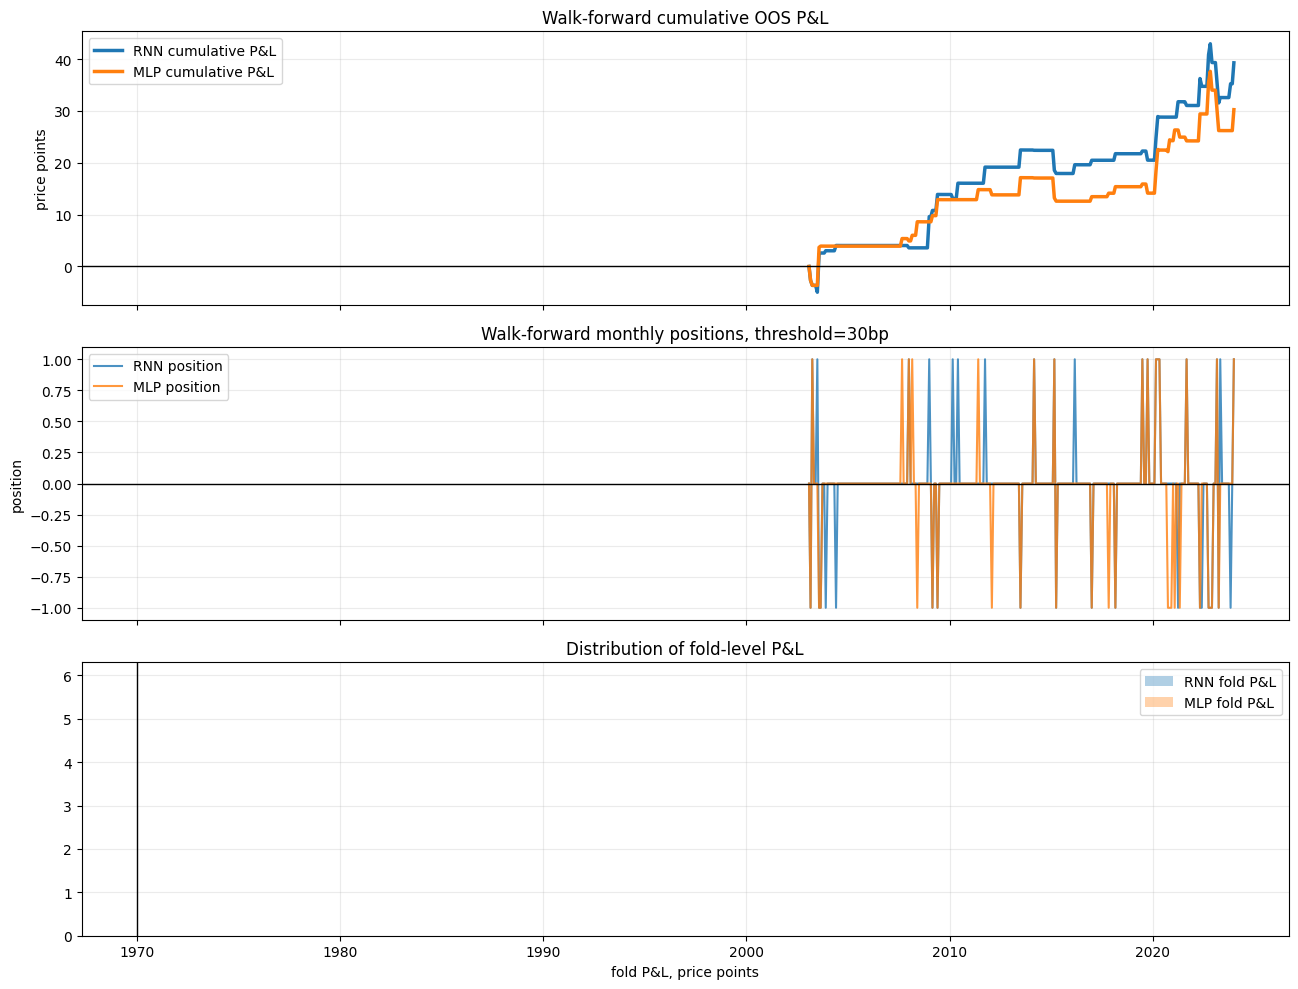

In [16]:
# ----------------------------
# Aggregate stats + plots
# ----------------------------

summary_oos = monthly_tbl.groupby("arch").agg(
    n_months=("monthly_pnl", "count"),
    total_pnl=("monthly_pnl", "sum"),
    total_pnl_bp=("monthly_pnl_bp", "sum"),
    mean_monthly_pnl=("monthly_pnl", "mean"),
    vol_monthly_pnl=("monthly_pnl", "std"),
    pct_long=("position", lambda x: np.mean(x == 1)),
    pct_short=("position", lambda x: np.mean(x == -1)),
    pct_flat=("position", lambda x: np.mean(x == 0)),
    active_win_rate=("monthly_pnl", lambda x: np.mean(x > 0)),
).reset_index()

summary_oos["sharpe_ann"] = summary_oos["mean_monthly_pnl"] / summary_oos["vol_monthly_pnl"] * np.sqrt(12)

fold_summary = fold_tbl.groupby("arch").agg(
    n_folds=("fold_id", "count"),
    mean_fold_pnl=("total_pnl", "mean"),
    median_fold_pnl=("total_pnl", "median"),
    pct_folds_positive=("total_pnl", lambda x: np.mean(x > 0)),
    mean_fold_sharpe=("sharpe_ann", "mean"),
    median_fold_sharpe=("sharpe_ann", "median"),
    total_cost_paid=("cost_paid", "sum"),
    avg_turnover=("turnover", "mean")
).reset_index()

display(summary_oos)
display(fold_summary)


fig, ax = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

for arch, color in [("rnn", "C0"), ("mlp", "C1")]:
    sub = monthly_tbl[monthly_tbl["arch"] == arch].sort_values("date")
    cum_pnl = sub["monthly_pnl"].cumsum()

    ax[0].plot(sub["date"], cum_pnl, color=color, linewidth=2.5, label=f"{arch.upper()} cumulative P&L")

ax[0].axhline(0, color="black", linewidth=1)
ax[0].set_title("Walk-forward cumulative OOS P&L")
ax[0].set_ylabel("price points")
ax[0].legend()
ax[0].grid(alpha=0.25)


for arch, color in [("rnn", "C0"), ("mlp", "C1")]:
    sub = monthly_tbl[monthly_tbl["arch"] == arch].sort_values("date")
    ax[1].plot(sub["date"], sub["position"], color=color, linewidth=1.5, alpha=0.8, label=f"{arch.upper()} position")

ax[1].axhline(0, color="black", linewidth=1)
ax[1].set_title(f"Walk-forward monthly positions, threshold={threshold_bp}bp")
ax[1].set_ylabel("position")
ax[1].legend()
ax[1].grid(alpha=0.25)


for arch, color in [("rnn", "C0"), ("mlp", "C1")]:
    vals = fold_tbl.loc[fold_tbl["arch"] == arch, "total_pnl"].values
    ax[2].hist(vals, bins=12, alpha=0.35, color=color, label=f"{arch.upper()} fold P&L")

ax[2].axvline(0, color="black", linewidth=1)
ax[2].set_title("Distribution of fold-level P&L")
ax[2].set_xlabel("fold P&L, price points")
ax[2].legend()
ax[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [17]:
# ----------------------------
# 1. Train/store RNN ensemble for interpretation
# ----------------------------

from sklearn.preprocessing import MinMaxScaler
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# use same test length as your latest final test plot
TEST_N = len(Yte_np) if "Yte_np" in globals() else 30

target_col = "Real Yield"
feature_cols = list(df_num.columns)

L = globals().get("L", 20)
hidden_size = globals().get("hidden_size", 8)
epochs_interp = globals().get("epochs", 500)
lr = globals().get("lr", 0.01)
weight_decay = globals().get("weight_decay", 1e-4)

threshold_bp = globals().get("threshold_bp", 30)
threshold = threshold_bp / 10_000

maturity = globals().get("maturity", 10)
notional = globals().get("notional", 100)

# transaction cost from 10Y spread in 256ths, if not already set
spread_256ths = globals().get("spread_256ths", 4.5)
cost_per_trade = globals().get("cost_per_trade", (spread_256ths / 256) / 2)

# clean and re-create final split to avoid overwritten walk-forward scalers
df_int = df_num.copy()
for c in df_int.columns:
    df_int[c] = pd.to_numeric(df_int[c], errors="coerce")

df_int = df_int.dropna().sort_index()

X_raw = df_int[feature_cols].values.astype(float)
y_raw = df_int[[target_col]].values.astype(float)

X_train_raw, X_test_raw = X_raw[:-TEST_N], X_raw[-TEST_N:]
y_train_raw, y_test_raw = y_raw[:-TEST_N], y_raw[-TEST_N:]

x_scaler_int = MinMaxScaler(feature_range=(-1, 1)).fit(X_train_raw)
y_scaler_int = MinMaxScaler(feature_range=(-1, 1)).fit(y_train_raw)

Xtr_int = torch.tensor(x_scaler_int.transform(X_train_raw), dtype=torch.float32)
Xte_int = torch.tensor(x_scaler_int.transform(X_test_raw), dtype=torch.float32)

Ytr_int = torch.tensor(y_scaler_int.transform(y_train_raw), dtype=torch.float32)
Yte_int = torch.tensor(y_scaler_int.transform(y_test_raw), dtype=torch.float32)

Ytr_np_int = y_train_raw.ravel()
Yte_np_int = y_test_raw.ravel()

train_dates_int = df_int.index[:len(Ytr_int)]
test_dates_int = df_int.index[len(Ytr_int):len(Ytr_int) + len(Yte_int)]


def make_seq_data_interp(L=20):
    X_all = torch.cat([Xtr_int, Xte_int], dim=0)
    Y_all = torch.cat([Ytr_int, Yte_int], dim=0)

    Xs, Ys = [], []
    for i in range(len(X_all) - L):
        Xs.append(X_all[i:i+L])
        Ys.append(Y_all[i+L])

    Xs = torch.stack(Xs)
    Ys = torch.stack(Ys)

    split = len(Xtr_int) - L
    return Xs[:split], Xs[split:], Ys[:split], Ys[split:]


def train_rnn_interp(seed, L=20, hidden_size=8, epochs=500, lr=0.01, weight_decay=1e-4):
    torch.manual_seed(int(seed))
    np.random.seed(int(seed))

    Xtr_seq, Xte_seq, Ytr_seq, Yte_seq = make_seq_data_interp(L=L)

    n_features = Xtr_seq.shape[-1]

    rnn = torch.nn.RNN(
        input_size=n_features,
        hidden_size=hidden_size,
        batch_first=True
    )
    out = torch.nn.Linear(hidden_size, 1)

    opt = torch.optim.Adam(
        list(rnn.parameters()) + list(out.parameters()),
        lr=lr,
        weight_decay=weight_decay
    )

    loss_fn = torch.nn.MSELoss()

    for epoch in range(epochs):
        opt.zero_grad()

        h, _ = rnn(Xtr_seq)
        pred = out(h[:, -1, :])

        loss = loss_fn(pred, Ytr_seq)
        loss.backward()
        opt.step()

    rnn.eval()
    out.eval()

    return rnn, out


def predict_rnn_ensemble(models, Xseq):
    preds = []

    with torch.no_grad():
        for rnn, out in models:
            h, _ = rnn(Xseq)
            pred_scaled = out(h[:, -1, :])
            pred_np = y_scaler_int.inverse_transform(pred_scaled.numpy()).ravel()
            preds.append(pred_np)

    pred_stack = np.stack(preds, axis=0)
    pred_mean = pred_stack.mean(axis=0)

    return pred_stack, pred_mean


Xtr_seq_int, Xte_seq_int, Ytr_seq_int, Yte_seq_int = make_seq_data_interp(L=L)

seeds_interp = seeds if "seeds" in globals() else np.arange(10)

rnn_models_interp = []

for s in tqdm(seeds_interp, desc="Training RNN ensemble for interpretation"):
    rnn_models_interp.append(
        train_rnn_interp(
            seed=s,
            L=L,
            hidden_size=hidden_size,
            epochs=epochs_interp,
            lr=lr,
            weight_decay=weight_decay
        )
    )

base_pred_stack, base_pred_mean = predict_rnn_ensemble(rnn_models_interp, Xte_seq_int)

print("Stored RNN models:", len(rnn_models_interp))
print("Test prediction shape:", base_pred_mean.shape)
print("Test horizon:", test_dates_int[0], "to", test_dates_int[-1])

Training RNN ensemble for interpretation:   0%|          | 0/10 [00:00<?, ?it/s]

Stored RNN models: 10
Test prediction shape: (30,)
Test horizon: 2021-10-29 00:00:00 to 2024-03-29 00:00:00


Occlusion by lag/feature:   0%|          | 0/5 [00:00<?, ?it/s]

,feature,mean_abs_forecast_impact
0,US CPI - ALL URBAN: ALL ITEMS SADJ,0.002240
1,Real Yield,0.002118
2,TOTMKUS(PI)/TOTMKUS(PE),0.001703
3,Steepness,0.001391
4,US GVT EVAL BMK BID YLD 3M - RED. YIELD,0.000734
5,US-DS Market - PER,0.000601
6,US GVT EVAL BMK BID YLD 10Y - RED. YIELD,0.000453
7,12M FWD E,0.000215


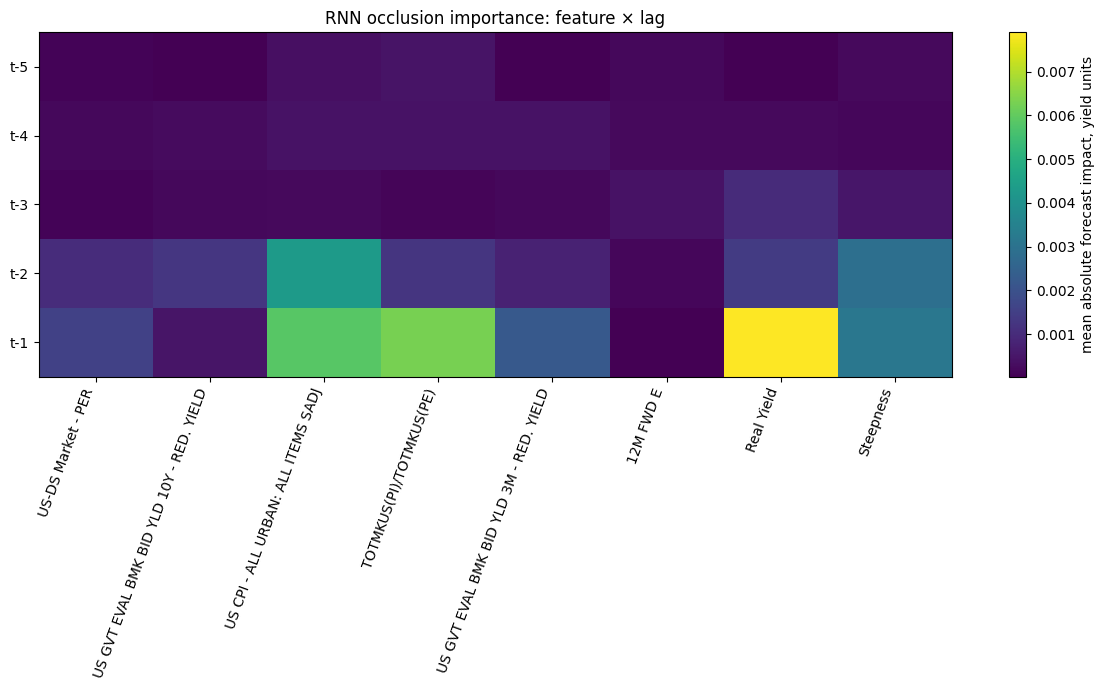

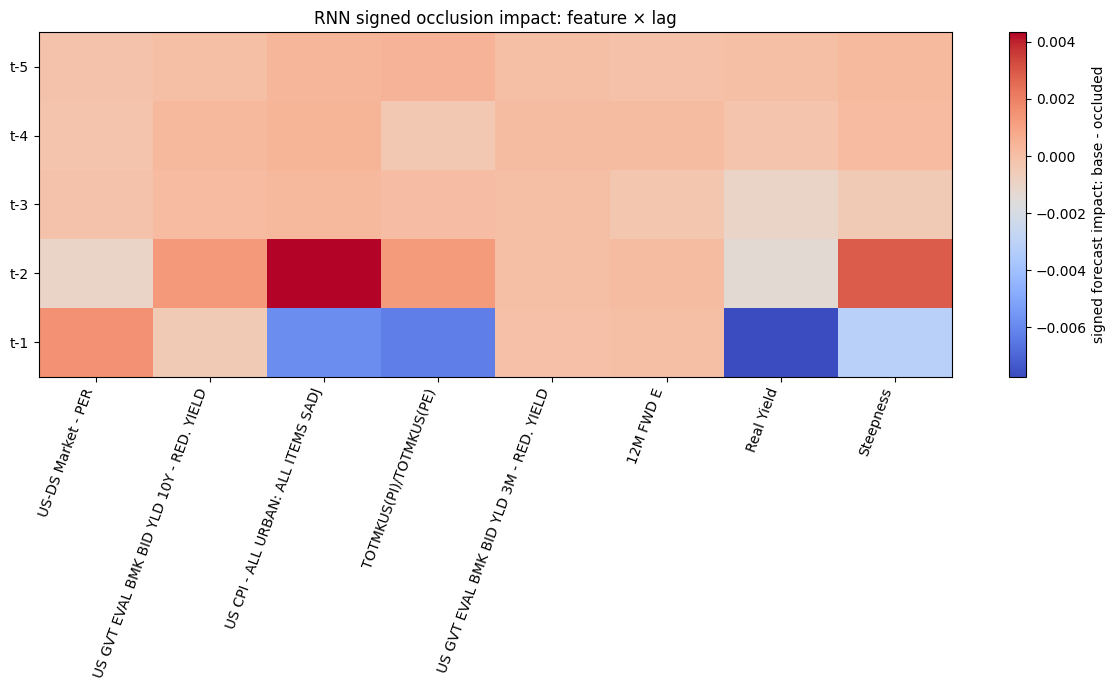

In [18]:
# ----------------------------
# 2. Prediction occlusion heatmap
# Measures how much neutralizing one feature/lag changes the RNN forecast
# ----------------------------

train_mean_scaled = Xtr_int.mean(dim=0)

n_lags = Xte_seq_int.shape[1]
n_features = Xte_seq_int.shape[2]

imp_abs = np.zeros((n_lags, n_features))
imp_signed = np.zeros((n_lags, n_features))

for lag in tqdm(range(n_lags), desc="Occlusion by lag/feature"):
    for j in range(n_features):
        X_occ = Xte_seq_int.clone()
        X_occ[:, lag, j] = train_mean_scaled[j]

        _, occ_pred_mean = predict_rnn_ensemble(rnn_models_interp, X_occ)

        diff = base_pred_mean - occ_pred_mean

        imp_abs[lag, j] = np.mean(np.abs(diff))
        imp_signed[lag, j] = np.mean(diff)

lag_labels = [f"t-{n_lags-i}" for i in range(n_lags)]

imp_abs_df = pd.DataFrame(
    imp_abs,
    index=lag_labels,
    columns=feature_cols
)

imp_signed_df = pd.DataFrame(
    imp_signed,
    index=lag_labels,
    columns=feature_cols
)

feature_importance = imp_abs_df.mean(axis=0).sort_values(ascending=False)

display(
    feature_importance
    .rename("mean_abs_forecast_impact")
    .reset_index()
    .rename(columns={"index": "feature"})
)

plt.figure(figsize=(12, 7))
plt.imshow(imp_abs_df.values, aspect="auto", cmap="viridis")
plt.colorbar(label="mean absolute forecast impact, yield units")
plt.xticks(np.arange(len(feature_cols)), feature_cols, rotation=70, ha="right")
plt.yticks(np.arange(n_lags), lag_labels)
plt.title("RNN occlusion importance: feature × lag")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
plt.imshow(imp_signed_df.values, aspect="auto", cmap="coolwarm")
plt.colorbar(label="signed forecast impact: base - occluded")
plt.xticks(np.arange(len(feature_cols)), feature_cols, rotation=70, ha="right")
plt.yticks(np.arange(n_lags), lag_labels)
plt.title("RNN signed occlusion impact: feature × lag")
plt.tight_layout()
plt.show()

Signal attribution:   0%|          | 0/5 [00:00<?, ?it/s]

,feature,mean_position_change_rate
0,Real Yield,0.113333
1,Steepness,0.040000
2,US GVT EVAL BMK BID YLD 3M - RED. YIELD,0.033333
3,US-DS Market - PER,0.026667
4,US CPI - ALL URBAN: ALL ITEMS SADJ,0.020000
5,TOTMKUS(PI)/TOTMKUS(PE),0.020000
6,12M FWD E,0.013333
7,US GVT EVAL BMK BID YLD 10Y - RED. YIELD,0.006667


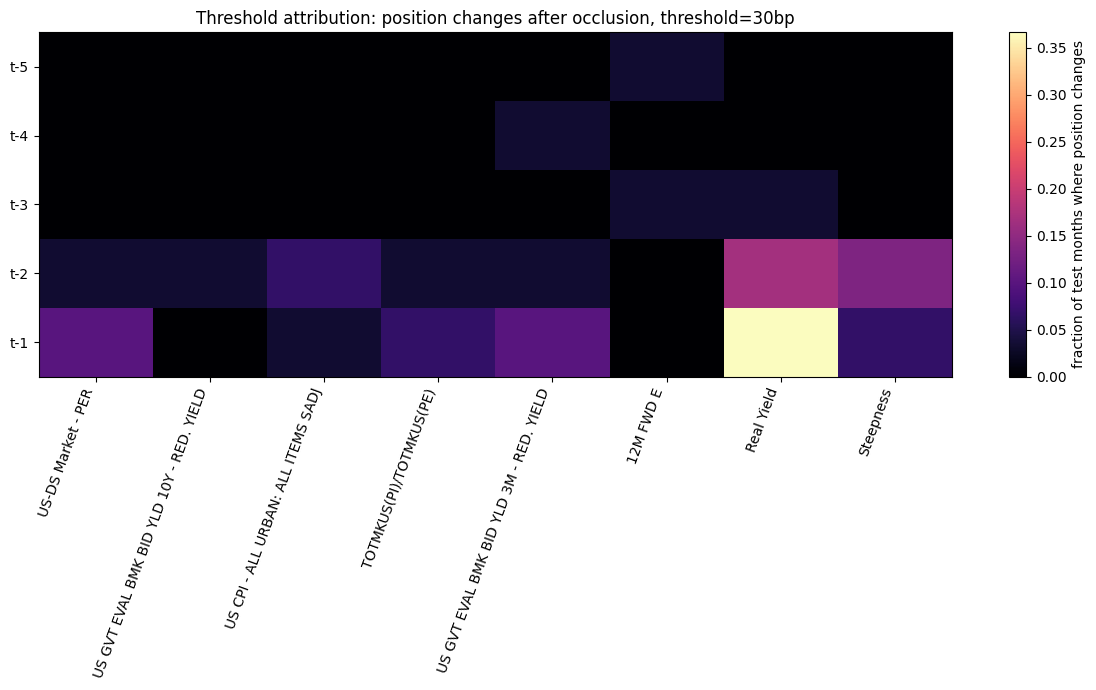

,lag,feature,n_position_changes,position_change_rate
15,t-1,Real Yield,11.0,0.366667
9,t-2,Real Yield,5.0,0.166667
10,t-2,Steepness,4.0,0.133333
14,t-1,US GVT EVAL BMK BID YLD 3M - RED. YIELD,3.0,0.100000
11,t-1,US-DS Market - PER,3.0,0.100000
16,t-1,Steepness,2.0,0.066667
13,t-1,TOTMKUS(PI)/TOTMKUS(PE),2.0,0.066667
6,t-2,US CPI - ALL URBAN: ALL ITEMS SADJ,2.0,0.066667
12,t-1,US CPI - ALL URBAN: ALL ITEMS SADJ,1.0,0.033333
0,t-5,12M FWD E,1.0,0.033333


In [19]:
# ----------------------------
# 3. Signal-threshold attribution
# Measures whether neutralizing feature/lag changes the trading signal
# ----------------------------

def positions_from_pred_path(pred_y, y0, threshold):
    pred_path = np.r_[y0, pred_y]
    pred_next_yield_change = np.diff(pred_path)

    positions = np.where(
        pred_next_yield_change <= -threshold, 1,
        np.where(pred_next_yield_change >= threshold, -1, 0)
    )

    return positions, pred_next_yield_change


base_positions, base_pred_dy = positions_from_pred_path(
    base_pred_mean,
    y0=Ytr_np_int[-1],
    threshold=threshold
)

signal_change_rate = np.zeros((n_lags, n_features))
signal_change_count = np.zeros((n_lags, n_features))

for lag in tqdm(range(n_lags), desc="Signal attribution"):
    for j in range(n_features):
        X_occ = Xte_seq_int.clone()
        X_occ[:, lag, j] = train_mean_scaled[j]

        _, occ_pred_mean = predict_rnn_ensemble(rnn_models_interp, X_occ)

        occ_positions, occ_pred_dy = positions_from_pred_path(
            occ_pred_mean,
            y0=Ytr_np_int[-1],
            threshold=threshold
        )

        changed = occ_positions != base_positions

        signal_change_rate[lag, j] = np.mean(changed)
        signal_change_count[lag, j] = np.sum(changed)

signal_change_df = pd.DataFrame(
    signal_change_rate,
    index=lag_labels,
    columns=feature_cols
)

signal_feature_summary = signal_change_df.mean(axis=0).sort_values(ascending=False)

display(
    signal_feature_summary
    .rename("mean_position_change_rate")
    .reset_index()
    .rename(columns={"index": "feature"})
)

plt.figure(figsize=(12, 7))
plt.imshow(signal_change_df.values, aspect="auto", cmap="magma")
plt.colorbar(label="fraction of test months where position changes")
plt.xticks(np.arange(len(feature_cols)), feature_cols, rotation=70, ha="right")
plt.yticks(np.arange(n_lags), lag_labels)
plt.title(f"Threshold attribution: position changes after occlusion, threshold={threshold_bp}bp")
plt.tight_layout()
plt.show()

signal_detail = []

for lag in range(n_lags):
    for j, feat in enumerate(feature_cols):
        if signal_change_count[lag, j] > 0:
            signal_detail.append({
                "lag": lag_labels[lag],
                "feature": feat,
                "n_position_changes": signal_change_count[lag, j],
                "position_change_rate": signal_change_rate[lag, j],
            })

signal_detail = pd.DataFrame(signal_detail).sort_values(
    "position_change_rate",
    ascending=False
)

display(signal_detail.head(25))

Strategy factor ablation:   0%|          | 0/8 [00:00<?, ?it/s]

,case,total_pnl,total_pnl_bp,mean_monthly_pnl,vol_monthly_pnl,sharpe_ann,active_win_rate,n_long,n_short,n_flat,turnover,cost_paid,delta_pnl_vs_full,delta_sharpe_vs_full
7,neutralize: Real Yield,-0.645030,-64.502987,-0.021501,0.116117,-0.641437,0.000000,0,1,29,2,0.017578,-11.860975,-1.271957
3,neutralize: US CPI - ALL URBAN: ALL ITEMS SADJ,7.599555,759.955508,0.253319,2.179118,0.402696,0.545455,4,7,19,14,0.123047,-3.616390,-0.227825
5,neutralize: US GVT EVAL BMK BID YLD 3M - RED. ...,7.599555,759.955508,0.253319,2.179118,0.402696,0.545455,4,7,19,14,0.123047,-3.616390,-0.227825
4,neutralize: TOTMKUS(PI)/TOTMKUS(PE),9.100760,910.075998,0.303359,2.154536,0.487745,0.600000,4,6,20,14,0.123047,-2.115186,-0.142775
0,full model,11.215946,1121.594557,0.373865,2.054027,0.630520,0.600000,3,7,20,12,0.105469,0.000000,0.000000
1,neutralize: US-DS Market - PER,11.222049,1122.204865,0.374068,2.053700,0.630964,0.600000,4,6,20,14,0.123047,0.006103,0.000443
2,neutralize: US GVT EVAL BMK BID YLD 10Y - RED....,11.825819,1182.581919,0.394194,2.053308,0.665038,0.636364,4,7,19,14,0.123047,0.609874,0.034518
6,neutralize: 12M FWD E,11.825819,1182.581919,0.394194,2.053308,0.665038,0.636364,4,7,19,14,0.123047,0.609874,0.034518
8,neutralize: Steepness,15.394412,1539.441229,0.513147,1.868778,0.951206,0.666667,3,6,21,10,0.087891,4.178467,0.320686


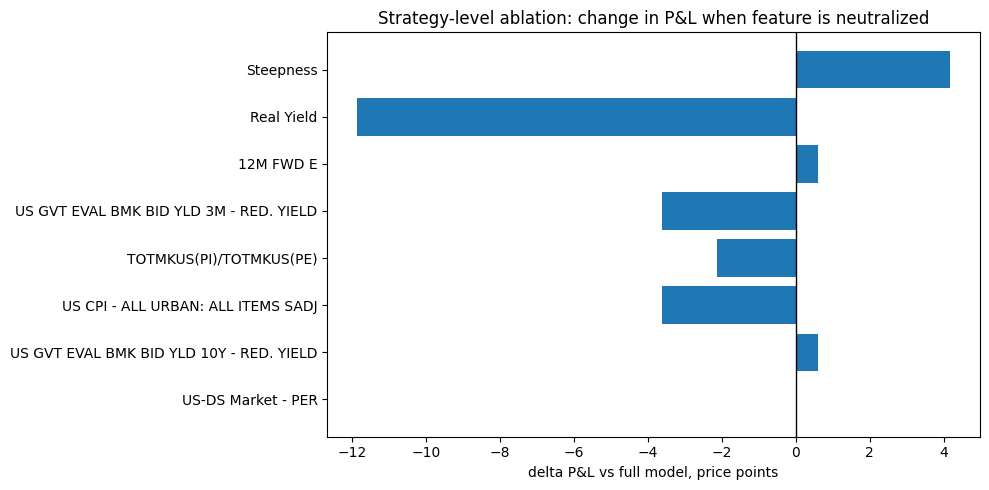

In [20]:
# ----------------------------
# 4A. Strategy-level factor ablation
# Fast version: neutralize one feature across all lags at prediction time.
# This does not retrain the RNN.
# ----------------------------

def naive_bond_price(y_decimal, maturity=10, notional=100):
    return notional / (1 + np.asarray(y_decimal)) ** maturity


def strategy_from_pred_mean(pred_y_mean, label):
    y_realized_path = np.r_[Ytr_np_int[-1], Yte_np_int]
    price_realized_path = naive_bond_price(
        y_realized_path,
        maturity=maturity,
        notional=notional
    )

    actual_price_change = np.diff(price_realized_path)

    positions, pred_next_yield_change = positions_from_pred_path(
        pred_y_mean,
        y0=Ytr_np_int[-1],
        threshold=threshold
    )

    monthly_pnl = positions * actual_price_change

    prev_positions = np.r_[0, positions[:-1]]
    turnover_entry_rebalance = np.abs(positions - prev_positions)
    turnover_exit = abs(positions[-1])

    monthly_pnl = monthly_pnl - turnover_entry_rebalance * cost_per_trade
    monthly_pnl[-1] -= turnover_exit * cost_per_trade

    total_turnover = turnover_entry_rebalance.sum() + turnover_exit

    sd = monthly_pnl.std(ddof=1)
    sharpe = monthly_pnl.mean() / sd * np.sqrt(12) if sd > 0 else np.nan

    active = positions != 0
    active_win_rate = np.mean(monthly_pnl[active] > 0) if active.sum() > 0 else np.nan

    return {
        "case": label,
        "total_pnl": monthly_pnl.sum(),
        "total_pnl_bp": monthly_pnl.sum() / notional * 10_000,
        "mean_monthly_pnl": monthly_pnl.mean(),
        "vol_monthly_pnl": sd,
        "sharpe_ann": sharpe,
        "active_win_rate": active_win_rate,
        "n_long": np.sum(positions == 1),
        "n_short": np.sum(positions == -1),
        "n_flat": np.sum(positions == 0),
        "turnover": total_turnover,
        "cost_paid": total_turnover * cost_per_trade,
    }


ablation_rows = []

full_stats = strategy_from_pred_mean(base_pred_mean, "full model")
ablation_rows.append(full_stats)

for j, feat in enumerate(tqdm(feature_cols, desc="Strategy factor ablation")):
    X_occ = Xte_seq_int.clone()
    X_occ[:, :, j] = train_mean_scaled[j]

    _, occ_pred_mean = predict_rnn_ensemble(rnn_models_interp, X_occ)

    row = strategy_from_pred_mean(occ_pred_mean, f"neutralize: {feat}")
    ablation_rows.append(row)

ablation_tbl = pd.DataFrame(ablation_rows)

full_pnl = ablation_tbl.loc[ablation_tbl["case"] == "full model", "total_pnl"].iloc[0]
full_sharpe = ablation_tbl.loc[ablation_tbl["case"] == "full model", "sharpe_ann"].iloc[0]

ablation_tbl["delta_pnl_vs_full"] = ablation_tbl["total_pnl"] - full_pnl
ablation_tbl["delta_sharpe_vs_full"] = ablation_tbl["sharpe_ann"] - full_sharpe

display(ablation_tbl.sort_values("delta_pnl_vs_full"))

plot_tbl = ablation_tbl[ablation_tbl["case"] != "full model"].copy()
plot_tbl["feature"] = plot_tbl["case"].str.replace("neutralize: ", "", regex=False)

plt.figure(figsize=(10, 5))
plt.barh(plot_tbl["feature"], plot_tbl["delta_pnl_vs_full"])
plt.axvline(0, color="black", linewidth=1)
plt.title("Strategy-level ablation: change in P&L when feature is neutralized")
plt.xlabel("delta P&L vs full model, price points")
plt.tight_layout()
plt.show()

,US-DS Market - PER,US GVT EVAL BMK BID YLD 10Y - RED. YIELD,US CPI - ALL URBAN: ALL ITEMS SADJ,TOTMKUS(PI)/TOTMKUS(PE),US GVT EVAL BMK BID YLD 3M - RED. YIELD,12M FWD E,Real Yield,Steepness
h0,0.418,-0.939,0.923,0.811,-0.899,0.104,-0.817,-0.114
h1,0.103,-0.280,0.329,0.182,-0.445,0.152,0.028,0.367
h2,-0.466,0.958,-0.923,-0.827,0.825,0.058,0.849,0.326
h3,0.462,-0.964,0.924,0.827,-0.844,-0.017,-0.861,-0.297
h4,-0.237,0.566,-0.296,-0.086,0.836,-0.282,0.453,-0.599
h5,0.181,-0.689,0.792,0.840,-0.429,-0.122,-0.764,-0.607
h6,0.079,-0.340,-0.011,-0.154,-0.624,0.391,-0.489,0.637
h7,-0.091,0.584,-0.473,-0.474,0.677,-0.022,0.842,-0.197


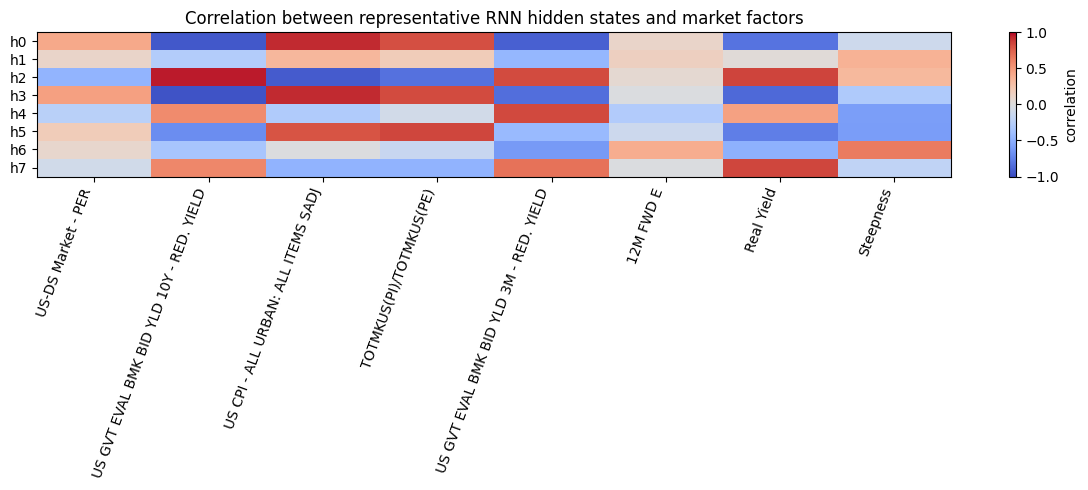

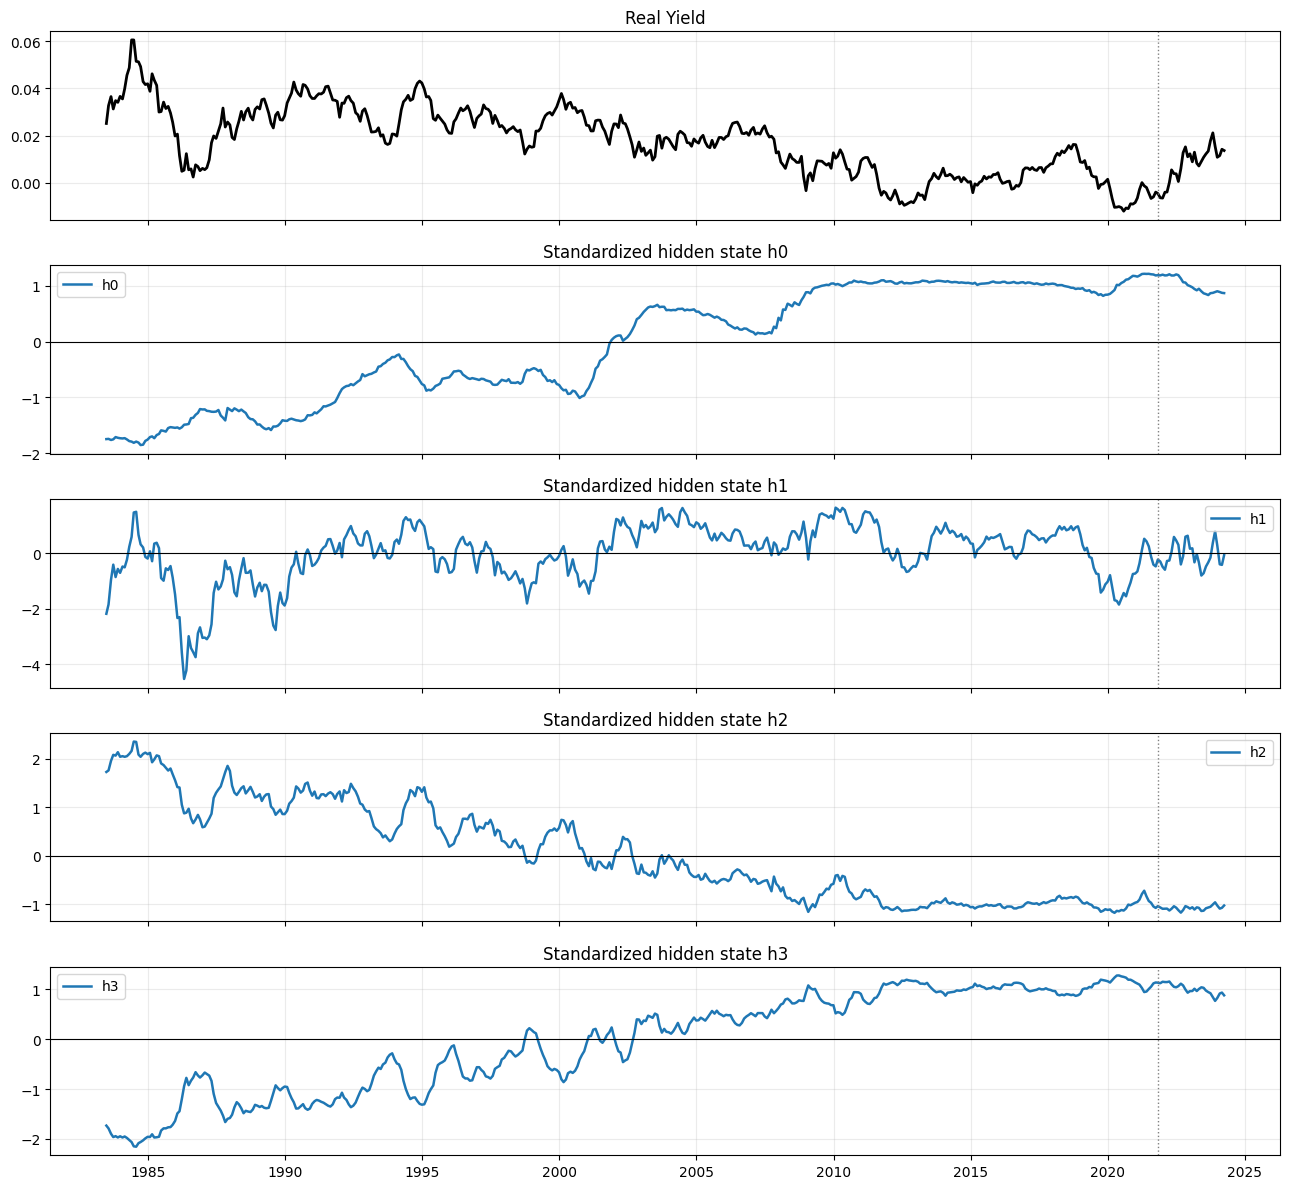

In [21]:
# ----------------------------
# 4B. Hidden-state regime plots
# Uses one representative RNN seed.
# Hidden dimensions can flip/rotate across seeds.
# Interpret as regime diagnostics, not structural factors.
# ----------------------------

rnn0, out0 = rnn_models_interp[0]

X_full_raw = df_int[feature_cols].values.astype(float)

X_full_scaled = torch.tensor(
    x_scaler_int.transform(X_full_raw),
    dtype=torch.float32
)

Xs_full = []
for i in range(len(X_full_scaled) - L):
    Xs_full.append(X_full_scaled[i:i+L])

Xs_full = torch.stack(Xs_full)
hidden_dates = df_int.index[L:]

with torch.no_grad():
    hseq, _ = rnn0(Xs_full)
    h_last = hseq[:, -1, :].numpy()

    pred_scaled = out0(hseq[:, -1, :])
    pred_hidden_np = y_scaler_int.inverse_transform(pred_scaled.numpy()).ravel()

h_cols = [f"h{i}" for i in range(h_last.shape[1])]

h_df = pd.DataFrame(h_last, index=hidden_dates, columns=h_cols)
h_df["pred_yield"] = pred_hidden_np

for c in feature_cols:
    h_df[c] = df_int.loc[hidden_dates, c].values

corr_tbl = pd.DataFrame(index=h_cols, columns=feature_cols)

for h in h_cols:
    for c in feature_cols:
        corr_tbl.loc[h, c] = h_df[h].corr(h_df[c])

corr_tbl = corr_tbl.astype(float)

display(corr_tbl.round(3))

plt.figure(figsize=(12, 5))
plt.imshow(corr_tbl.values, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="correlation")
plt.xticks(np.arange(len(feature_cols)), feature_cols, rotation=70, ha="right")
plt.yticks(np.arange(len(h_cols)), h_cols)
plt.title("Correlation between representative RNN hidden states and market factors")
plt.tight_layout()
plt.show()

n_plot_h = min(4, len(h_cols))

fig, ax = plt.subplots(n_plot_h + 1, 1, figsize=(13, 2.4 * (n_plot_h + 1)), sharex=True)

ax[0].plot(h_df.index, h_df[target_col], color="black", linewidth=2)
ax[0].axvline(test_dates_int[0], color="grey", linestyle=":", linewidth=1)
ax[0].set_title(target_col)
ax[0].grid(alpha=0.25)

for i in range(n_plot_h):
    h = h_cols[i]
    z = (h_df[h] - h_df[h].mean()) / h_df[h].std()

    ax[i + 1].plot(h_df.index, z, linewidth=1.8, label=h)
    ax[i + 1].axhline(0, color="black", linewidth=0.8)
    ax[i + 1].axvline(test_dates_int[0], color="grey", linestyle=":", linewidth=1)
    ax[i + 1].set_title(f"Standardized hidden state {h}")
    ax[i + 1].legend()
    ax[i + 1].grid(alpha=0.25)

plt.tight_layout()
plt.show()